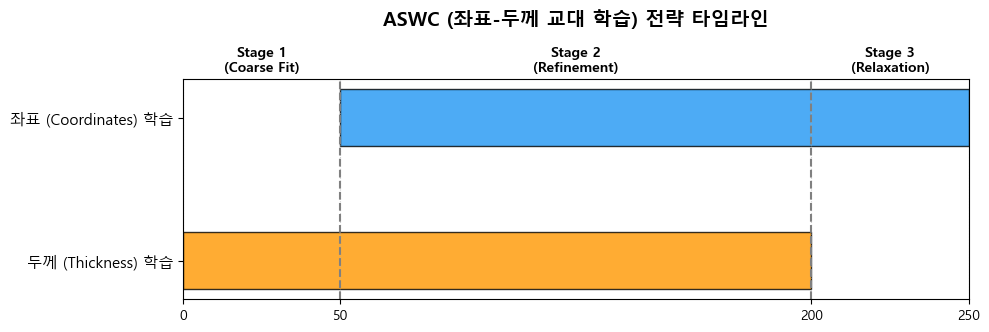

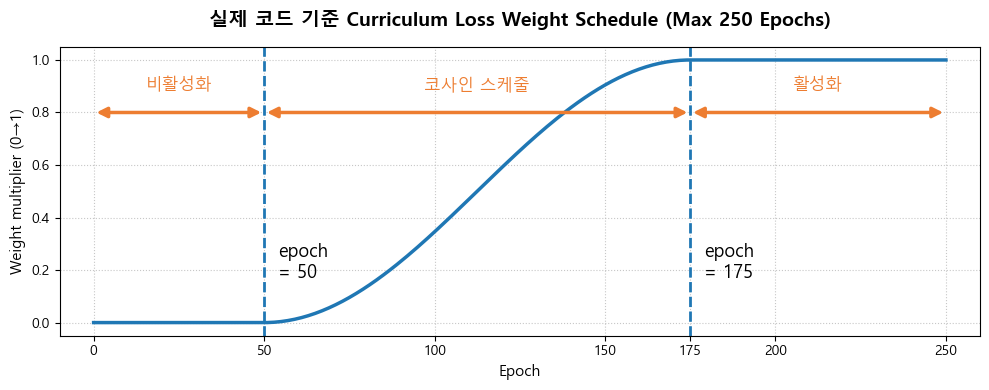

In [27]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# 한글 폰트 설정 (Windows 기준 맑은 고딕, Mac은 'AppleGothic' 사용 권장)
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

def plot_aswc_strategy():
    """
    1. ASWC (Alternating Shape and Width Curriculum) 전략 시각화
    - Stage 1 (0~50): 두께만 학습 (좌표 고정)
    - Stage 2 (50~200): 좌표 + 두께 동시 학습
    - Stage 3 (200~250): 좌표만 학습 (연속 파트 두께 고정)
    """
    fig, ax = plt.subplots(figsize=(10, 3.5))
    
    # 학습 구간 정의 (start, length)
    # y=10: 두께 학습 (0~200 에포크)
    ax.broken_barh([(0, 200)], (8, 4), facecolors='#FF9800', alpha=0.8, edgecolor='black')
    # y=20: 좌표 학습 (50~250 에포크)
    ax.broken_barh([(50, 200)], (18, 4), facecolors='#2196F3', alpha=0.8, edgecolor='black')
    
    # y축 설정
    ax.set_yticks([10, 20])
    ax.set_yticklabels(['두께 (Thickness) 학습', '좌표 (Coordinates) 학습'], fontsize=11)
    
    # x축 설정
    #ax.set_xlabel('Epoch', fontsize=12)
    ax.set_xlim(0, 250)
    ax.set_xticks([0, 50, 200, 250])
    
    # Stage 경계선 및 텍스트
    ax.axvline(x=50, color='gray', linestyle='--', linewidth=1.5)
    ax.axvline(x=200, color='gray', linestyle='--', linewidth=1.5)
    
    ax.text(25, 24, 'Stage 1\n(Coarse Fit)', ha='center', va='center', fontsize=10, fontweight='bold')
    ax.text(125, 24, 'Stage 2\n(Refinement)', ha='center', va='center', fontsize=10, fontweight='bold')
    ax.text(225, 24, 'Stage 3\n(Relaxation)', ha='center', va='center', fontsize=10, fontweight='bold')
    
    ax.set_title('ASWC (좌표-두께 교대 학습) 전략 타임라인', fontsize=14, fontweight='bold', pad=15, y=1.15)
    ax.grid(axis='x', linestyle=':', alpha=0.6)
    
    plt.tight_layout()
    plt.show()

def plot_curriculum_loss_schedule_actual():
    """
    실제 AI_design_v1.py 코드에 적용된 동적 Curriculum Loss Weight Schedule 시각화
    - max_epochs = 250
    - curriculum_ratio = (0.2, 0.7)
    - Phase 1 (비활성화): 0 ~ 50 epoch (250 * 0.2)
    - Phase 2 (코사인 상승): 50 ~ 175 epoch (250 * 0.7)
    - Phase 3 (완전 활성화): 175 ~ 250 epoch
    """
    max_epochs = 250
    ratio_a, ratio_b = 0.2, 0.7
    
    stage_a = int(max_epochs * ratio_a) # 50 에포크
    stage_b = int(max_epochs * ratio_b) # 175 에포크
    
    epochs = np.arange(0, max_epochs + 1)
    weights = np.zeros_like(epochs, dtype=float)
    
    # 실제 수식: progress = 0.5 * (1 + sin(pi * (x - 0.5)))
    for i, ep in enumerate(epochs):
        if ep < stage_a:
            weights[i] = 0.0
        elif ep < stage_b:
            x = (ep - stage_a) / (stage_b - stage_a)
            weights[i] = 0.5 * (1 + np.sin(np.pi * (x - 0.5)))
        else:
            weights[i] = 1.0
            
    fig, ax = plt.subplots(figsize=(10, 4))
    
    # 메인 곡선
    ax.plot(epochs, weights, color='#1f77b4', linewidth=2.5)
    
    # 수직 점선
    ax.axvline(x=stage_a, color='#1f77b4', linestyle='--', linewidth=2.0)
    ax.axvline(x=stage_b, color='#1f77b4', linestyle='--', linewidth=2.0)
    
    # 화살표 및 텍스트 어노테이션
    arrow_color = '#ED7D31'
    arrow_style = '<|-|>'
    
    # 0 ~ 50 구간 (Phase 1)
    ax.annotate('', xy=(0, 0.8), xytext=(stage_a, 0.8),
                arrowprops=dict(arrowstyle=arrow_style, color=arrow_color, lw=2.5, mutation_scale=15))
    ax.text(stage_a / 2, 0.87, '비활성화', color=arrow_color, ha='center', va='bottom', fontsize=12)
    
    # 50 ~ 175 구간 (Phase 2)
    ax.annotate('', xy=(stage_a, 0.8), xytext=(stage_b, 0.8),
                arrowprops=dict(arrowstyle=arrow_style, color=arrow_color, lw=2.5, mutation_scale=15))
    ax.text((stage_a + stage_b) / 2, 0.87, '코사인 스케줄', color=arrow_color, ha='center', va='bottom', fontsize=12)
    
    # 175 ~ 250 구간 (Phase 3)
    ax.annotate('', xy=(stage_b, 0.8), xytext=(max_epochs, 0.8),
                arrowprops=dict(arrowstyle=arrow_style, color=arrow_color, lw=2.5, mutation_scale=15))
    ax.text((stage_b + max_epochs) / 2, 0.87, '활성화', color=arrow_color, ha='center', va='bottom', fontsize=12)
    
    # Epoch 텍스트 마커
    ax.text(stage_a + 4, 0.23, f'epoch\n= {stage_a}', ha='left', va='center', fontsize=13)
    ax.text(stage_b + 4, 0.23, f'epoch\n= {stage_b}', ha='left', va='center', fontsize=13)
    
    # 축 및 그리드 설정
    ax.set_xlim(-10, max_epochs + 10)
    ax.set_ylim(-0.05, 1.05)
    ax.set_xticks([0, 50, 100, 150, 175, 200, 250])
    ax.set_xlabel('Epoch', fontsize=11)
    ax.set_ylabel('Weight multiplier (0→1)', fontsize=11)
    ax.set_title('실제 코드 기준 Curriculum Loss Weight Schedule (Max 250 Epochs)', fontsize=14, fontweight='bold', pad=15)
    
    ax.grid(True, linestyle=':', alpha=0.7)
    
    plt.tight_layout()
    plt.show()

# 실행
if __name__ == "__main__":
    plot_aswc_strategy()
    plot_curriculum_loss_schedule_actual()